# Introduction
- Create a quick forecasting model with Prophet for benchmarking later models
- Steps:
    1. Load the data
    1. Prepare the data
    1. Train, test, and evaluation split
    1. Model development
    1. Model evaluation
        - MAE: primary metric - operational interpretability (€/MWh)
        - RMSE: secondary metric - sensitivity to spikes
        - MASE: baseline - are you beating the naive "same hour last week"

# Environment Setup

In [1]:
import os
from pathlib import Path

WORKING_DIRECTORY = Path.cwd().parents[0]
os.chdir(WORKING_DIRECTORY)

 # Imports

In [2]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import numpy as np

/home/idloea/python/electricity-day-ahead-prices/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [3]:
DATA_PATH = Path("data")
DATA_FILE = 'electricity_dah_prices.csv'
data_file_path = DATA_PATH.joinpath(DATA_FILE)
print(f'data file path: {data_file_path}')

data file path: data/electricity_dah_prices.csv


In [4]:
data = pd.read_csv(data_file_path)
data.head()

,date,hour,france,italy,belgium,spain,uk,germany
0,2022/01/01,00:00 - 01:00,89.06,170.28,82.02,145.86,0.27,50.05
1,2022/01/01,01:00 - 02:00,78.48,155.72,67.07,114.90,-0.01,41.33
2,2022/01/01,02:00 - 03:00,85.16,147.09,75.11,113.87,0.27,43.22
3,2022/01/01,03:00 - 04:00,50.00,91.00,50.91,97.80,-0.01,45.46
4,2022/01/01,04:00 - 05:00,37.67,104.00,37.67,97.80,-0.01,37.67


In [5]:
def process_hours(df):
    hours = df['hour'].str.split('-', expand=True)
    df['start_hour'] = hours[0].str.strip()
    df['end_hour'] = hours[1].str.strip()
    return df

data = (
    data
    .pipe(process_hours)
    .assign(
        start_hour = lambda x: pd.to_datetime(x['start_hour'], format='%H:%M').dt.time,
        end_hour   = lambda x: pd.to_datetime(x['end_hour'], format='%H:%M').dt.time,
        date       = lambda x: pd.to_datetime(x['date']),
        datetime   = lambda x: x.apply(lambda row: pd.Timestamp.combine(row['date'], row['start_hour']), axis=1)
    )
)

data.head()

,date,hour,france,italy,belgium,spain,uk,germany,start_hour,end_hour,datetime
0,2022-01-01,00:00 - 01:00,89.06,170.28,82.02,145.86,0.27,50.05,00:00:00,01:00:00,2022-01-01 00:00:00
1,2022-01-01,01:00 - 02:00,78.48,155.72,67.07,114.90,-0.01,41.33,01:00:00,02:00:00,2022-01-01 01:00:00
2,2022-01-01,02:00 - 03:00,85.16,147.09,75.11,113.87,0.27,43.22,02:00:00,03:00:00,2022-01-01 02:00:00
3,2022-01-01,03:00 - 04:00,50.00,91.00,50.91,97.80,-0.01,45.46,03:00:00,04:00:00,2022-01-01 03:00:00
4,2022-01-01,04:00 - 05:00,37.67,104.00,37.67,97.80,-0.01,37.67,04:00:00,05:00:00,2022-01-01 04:00:00


# Data Preparation

## Imputation

In [6]:
# Check eda.py for more details on the missing values and how to handle them.
countries_of_interest = ['spain', 'france', 'italy', 'belgium', 'germany']
time_change_index = data[data[countries_of_interest].isnull().any(axis=1)].index[0]
data.iloc[time_change_index] = data.iloc[time_change_index - 1]
data.isnull().sum()

date             0
hour             0
france           0
italy            0
belgium          0
spain            0
uk            1441
germany          0
start_hour       0
end_hour         0
datetime         0
dtype: int64

# Train and test datasets

In [7]:
prophet_data = data[['datetime', 'france']]
prophet_data.rename(columns={'datetime': 'ds', 'france': 'y'}, inplace=True)

In [8]:
TRAIN_SIZE_PERCENTAGE = 0.9
test_size = 1 - TRAIN_SIZE_PERCENTAGE
train_size = int(len(prophet_data) * TRAIN_SIZE_PERCENTAGE) + 1
train_data = prophet_data.iloc[:train_size]
test_data = prophet_data.iloc[train_size:train_size + int(len(prophet_data) * test_size)]
test_data_size = len(test_data)

print(f' data shape: {prophet_data.shape}')
print(f'train_data shape: {train_data.shape}')
print(f'test_data shape: {test_data.shape}')
print(f'test_data size: {test_data_size}')

 data shape: (8761, 2)
train_data shape: (7885, 2)
test_data shape: (876, 2)
test_data size: 876


# Prophet Model

In [9]:
m = Prophet()
m.fit(train_data)

21:40:13 - cmdstanpy - INFO - Chain [1] start processing
21:40:15 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = m.make_future_dataframe(periods=test_data_size, freq='h')
future.tail()

,ds
8754,2022-12-31 19:00:00
8755,2022-12-31 20:00:00
8756,2022-12-31 21:00:00
8757,2022-12-31 22:00:00
8758,2022-12-31 23:00:00


In [11]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
8754,2022-12-31 19:00:00,14.908960,-372.303531,464.282731
8755,2022-12-31 20:00:00,9.760812,-414.942561,466.111990
8756,2022-12-31 21:00:00,-14.135653,-396.306525,423.093178
8757,2022-12-31 22:00:00,-41.993425,-447.150895,409.329525
8758,2022-12-31 23:00:00,-62.103181,-479.943018,388.413190


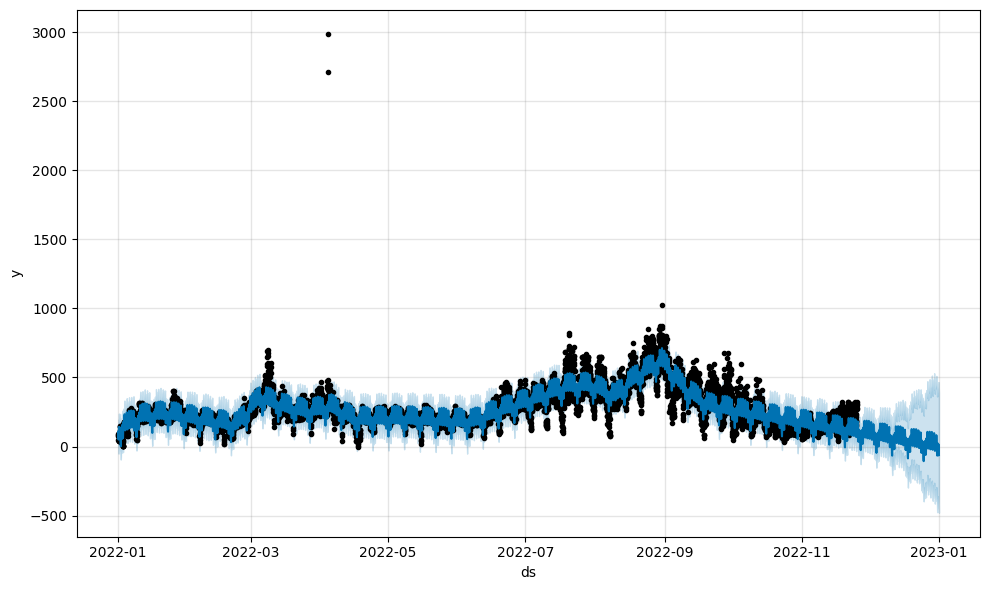

In [12]:
ig1 = m.plot(forecast)

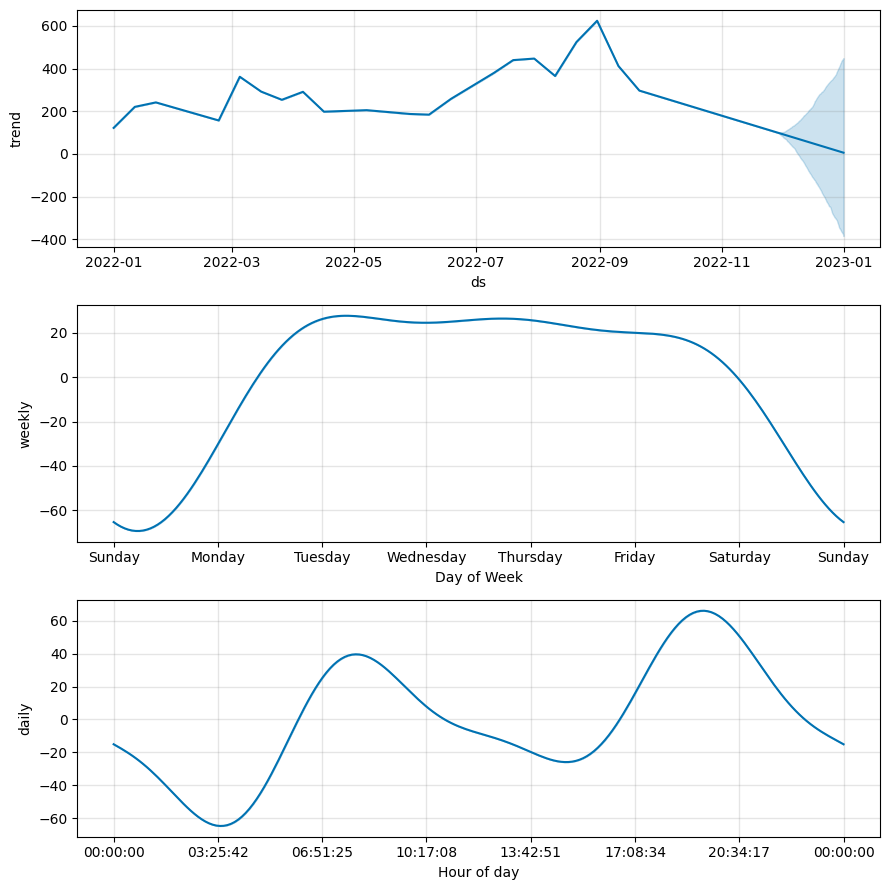

In [13]:
fig2 = m.plot_components(forecast)

In [14]:
merged_df = pd.merge(left=data, right=forecast[['ds', 'yhat']], left_on='datetime', right_on='ds', how='left')[['datetime', 'france', 'yhat']]
test_merged_df = merged_df[merged_df['datetime'] >= test_data['ds'].iloc[0]].reset_index(drop=True)
test_merged_df.head()

,datetime,france,yhat
0,2022-11-25 12:00:00,264.10,118.028290
1,2022-11-25 13:00:00,273.55,111.245942
2,2022-11-25 14:00:00,290.12,102.501378
3,2022-11-25 15:00:00,310.42,97.565121
4,2022-11-25 16:00:00,327.36,106.437530


# Evaluation

In [15]:
def compute_mase(actual, predicted, m=168):
    mae_forecast = np.mean(np.abs(actual - predicted))
    mae_naive = np.mean(np.abs(actual[m:] - actual[:-m]))
    return mae_forecast / mae_naive

mae = mean_absolute_error(test_merged_df['france'], test_merged_df['yhat'])
rmse = root_mean_squared_error(test_merged_df['france'], test_merged_df['yhat'])
mase_value = compute_mase(test_merged_df['france'].values, test_merged_df['yhat'].values)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Scaled Error (MASE): {mase_value}')

Mean Absolute Error (MAE): 220.27321490851088
Root Mean Squared Error (RMSE): 253.06006412563104
Mean Absolute Scaled Error (MASE): 1.949695296096191
